**Load Data**



In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub
import pandas as pd
import os

In [ ]:
path = kagglehub.dataset_download("ealaxi/paysim1")
df = pd.read_csv(os.path.join(path, "PS_20174392719_1491204439457_log.csv"))
print(df.shape)
df.head()

Using Colab cache for faster access to the 'paysim1' dataset.
(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
print(os.listdir(path))

['PS_20174392719_1491204439457_log.csv']


Step 1 — Basic overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst few rows:")
df.head()

Shape: (6362620, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First few rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Step 2 — Missing values aur duplicates check

In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


Step 3 — Target variable (isFraud) ka distribution

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.1291%


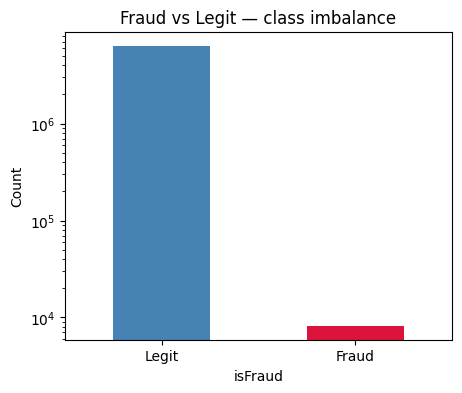

In [ ]:
print(df["isFraud"].value_counts())
print(f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%")

plt.figure(figsize=(5, 4))
df["isFraud"].value_counts().plot(kind="bar", color=["steelblue", "crimson"])
plt.title("Fraud vs Legit — class imbalance")
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.ylabel("Count")
plt.yscale("log")
plt.show()

Step 4 — type column distribution (categorical)

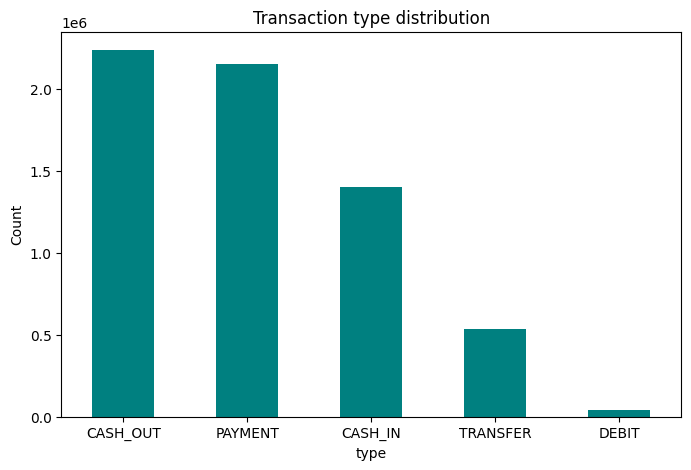

In [ ]:
plt.figure(figsize = (8,5))
df["type"].value_counts().plot(kind="bar", color="teal")
plt.title("Transaction type distribution")
plt.xticks(rotation = 0)
plt.ylabel("Count")
plt.show()

In [ ]:
print(df[df["isFraud"] == 1]["type"].value_counts())

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


this represents the fraund rate by transfer and cash_out types

Step 5 — Numeric columns ki skewness dekhna

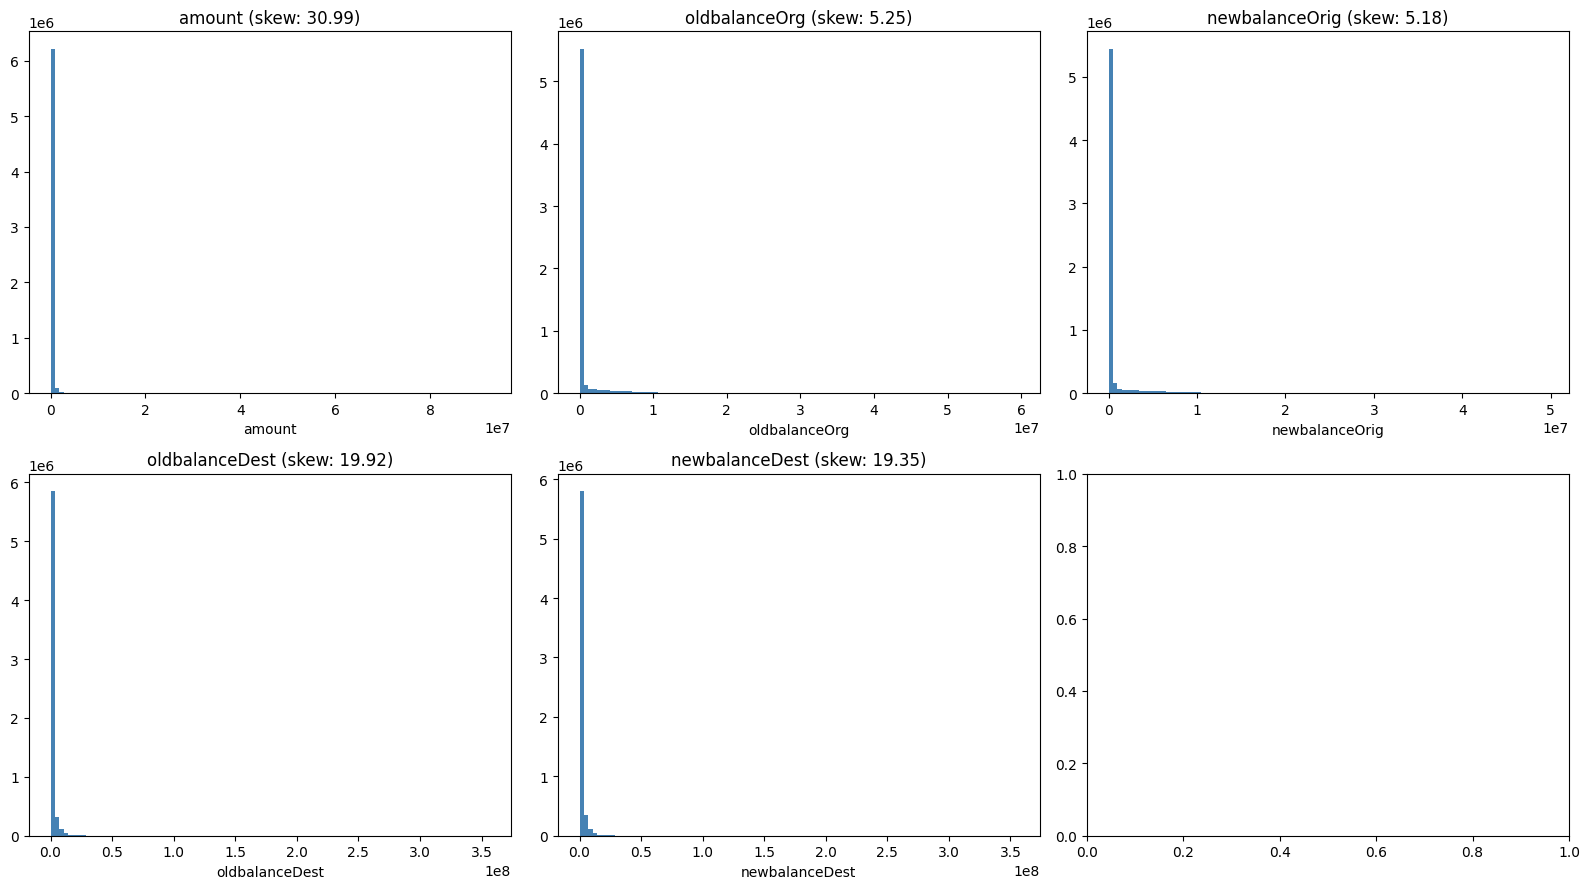

In [ ]:
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=100, color="steelblue")
    axes[i].set_title(f"{col} (skew: {df[col].skew():.2f})")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

Step 6 — Log-transformed view

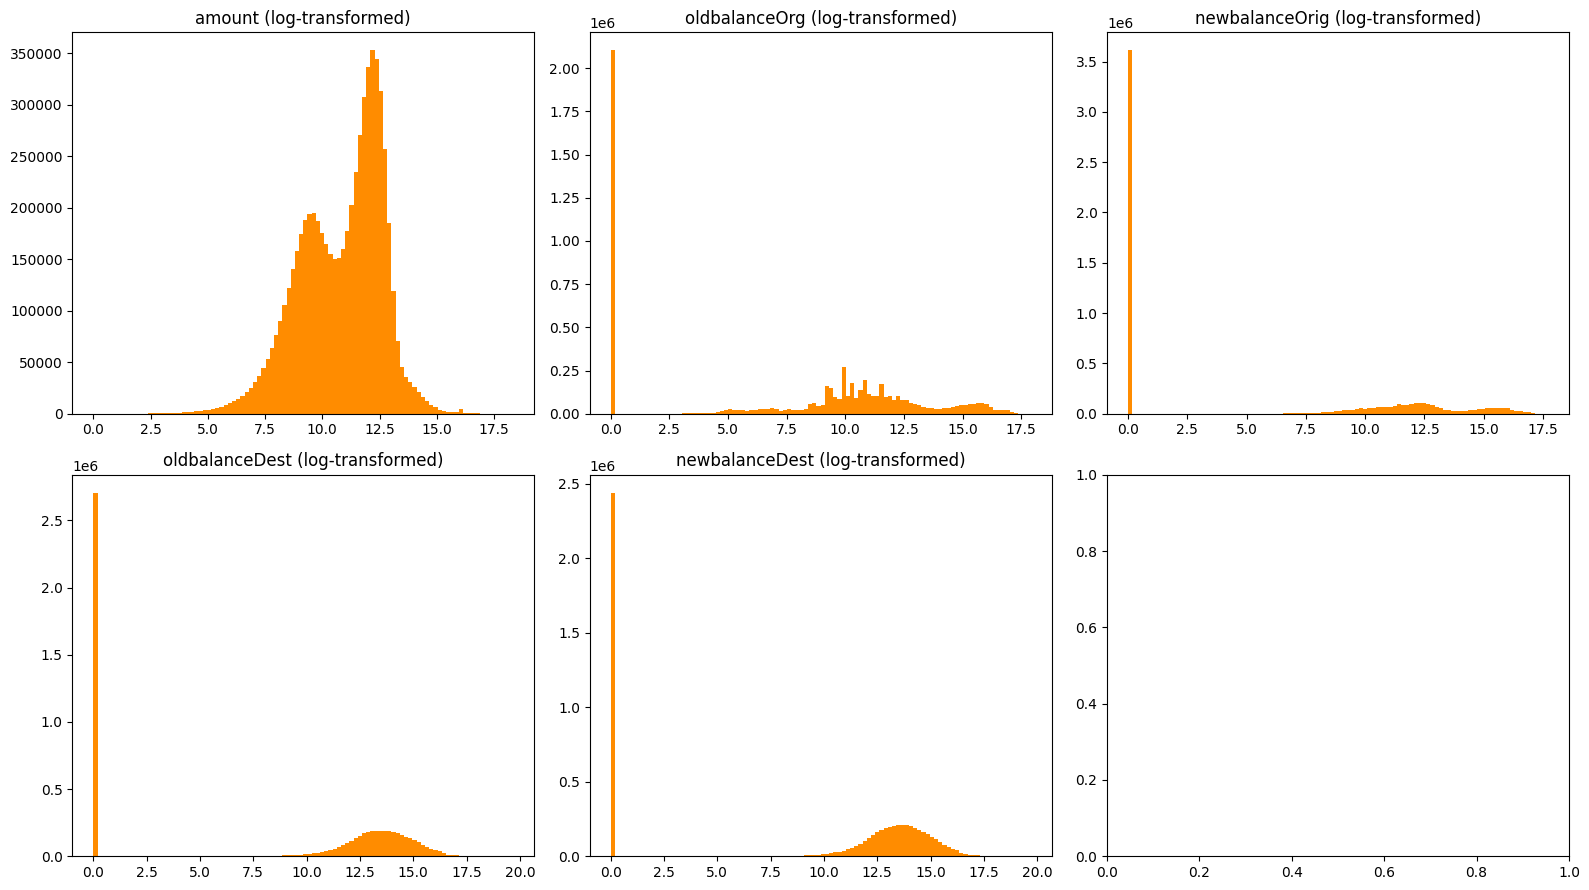

In [ ]:
ig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    log_data = np.log1p(df[col])   # log1p = log(1+x), zero values handle karta hai
    axes[i].hist(log_data, bins=100, color="darkorange")
    axes[i].set_title(f"{col} (log-transformed)")

plt.tight_layout()
plt.show()

Discovered that zero balances in origin/destination accounts carry fraud signal (e.g., transfers from already-empty accounts), and engineered a binary flag feature to capture this pattern explicitly, since log transformation alone couldn't resolve the zero-inflation in the distribution


Step 7 — Boxplots — outliers, fraud vs legit

/tmp/ipykernel_1376/2821473224.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legit", "Fraud"])
/tmp/ipykernel_1376/2821473224.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Legit", "Fraud"])


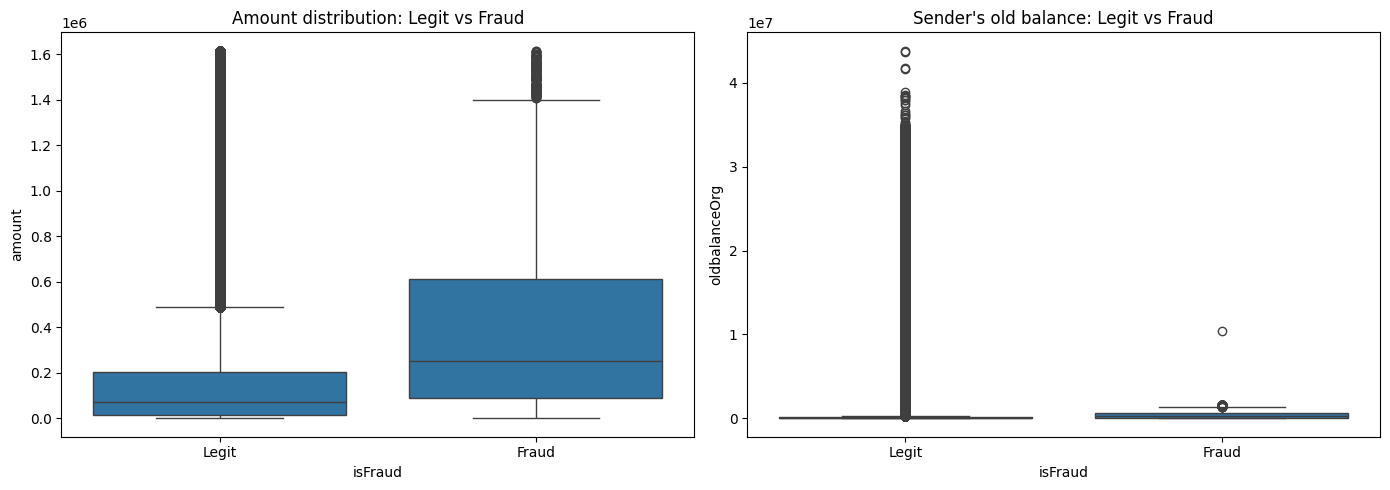

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


amount_capped = df[df["amount"] < df["amount"].quantile(0.99)]

sns.boxplot(x="isFraud", y="amount", data=amount_capped, ax=axes[0])
axes[0].set_title("Amount distribution: Legit vs Fraud")
axes[0].set_xticklabels(["Legit", "Fraud"])

sns.boxplot(x="isFraud", y="oldbalanceOrg", data=amount_capped, ax=axes[1])
axes[1].set_title("Sender's old balance: Legit vs Fraud")
axes[1].set_xticklabels(["Legit", "Fraud"])

plt.tight_layout()
plt.show()

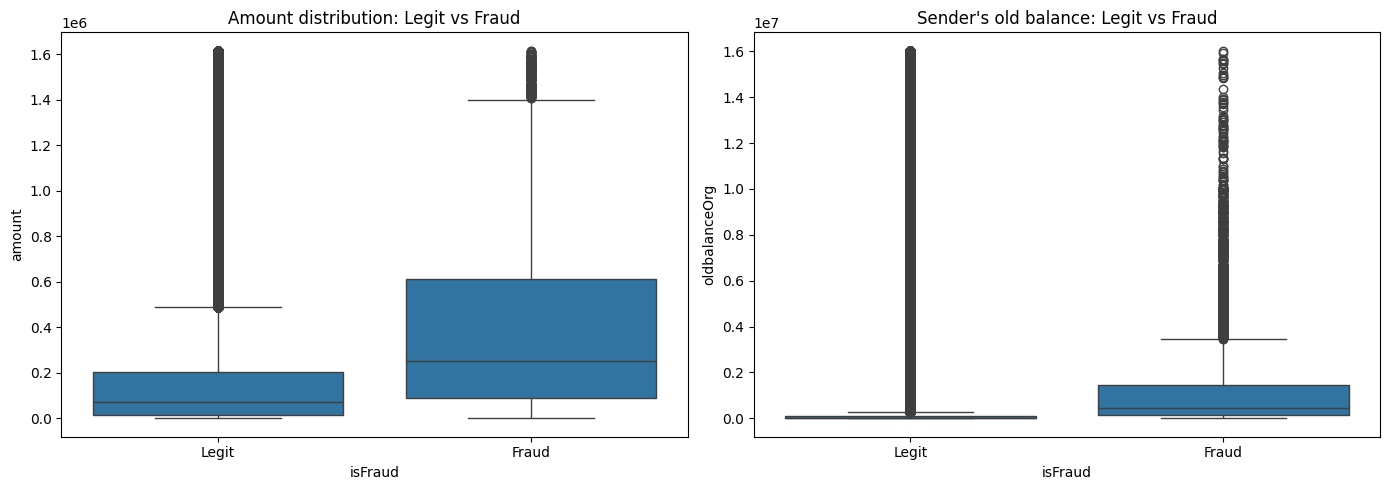

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amount_capped = df[df["amount"] < df["amount"].quantile(0.99)]
balance_capped = df[df["oldbalanceOrg"] < df["oldbalanceOrg"].quantile(0.99)]

sns.boxplot(x="isFraud", y="amount", data=amount_capped, ax=axes[0])
axes[0].set_title("Amount distribution: Legit vs Fraud")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legit", "Fraud"])

sns.boxplot(x="isFraud", y="oldbalanceOrg", data=balance_capped, ax=axes[1])
axes[1].set_title("Sender's old balance: Legit vs Fraud")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Legit", "Fraud"])

plt.tight_layout()
plt.show()

Step 8 — Correlation heatmap

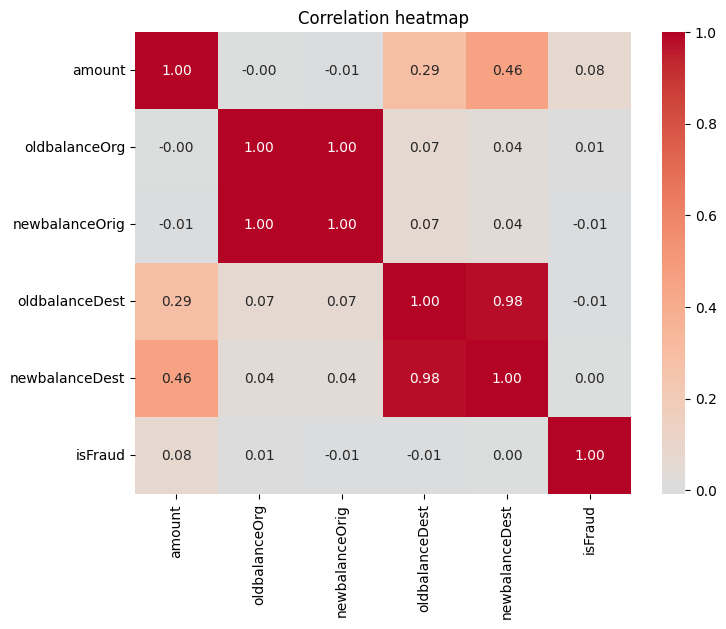

In [ ]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ["isFraud"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

Step 9 — balance discrepancy

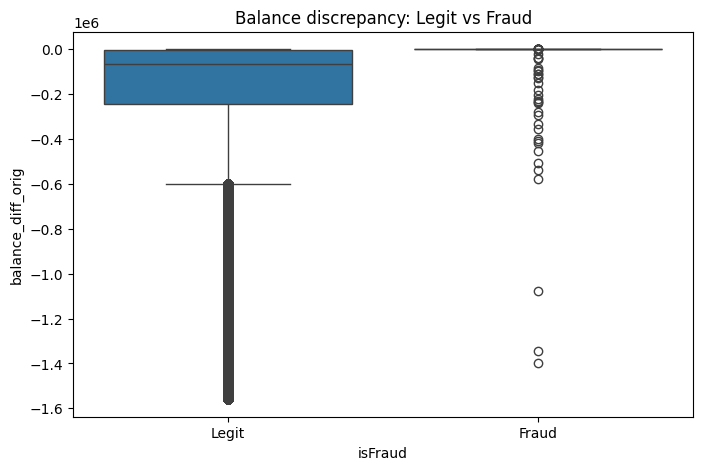

In [ ]:
df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]

plt.figure(figsize=(8, 5))
sns.boxplot(x="isFraud", y="balance_diff_orig",
            data=df[df["balance_diff_orig"].abs() < df["balance_diff_orig"].abs().quantile(0.99)])
plt.title("Balance discrepancy: Legit vs Fraud")
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.show()

**DATA CLEANING**

In [ ]:
df_clean = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

print("Shape after dropping ID columns:", df_clean.shape)

Shape after dropping ID columns: (6362620, 9)


Step 3 — Feature engineering: balance discrepancy

In [ ]:
# Sender ke balance ka mismatch
df_clean["balance_diff_orig"] = df_clean["oldbalanceOrg"] - df_clean["newbalanceOrig"] - df_clean["amount"]

# Receiver ke balance ka mismatch
df_clean["balance_diff_dest"] = df_clean["newbalanceDest"] - df_clean["oldbalanceDest"] - df_clean["amount"]

Step 4 — Zero-balance flags

In [ ]:
df_clean["orig_balance_was_zero"] = (df_clean["oldbalanceOrg"] == 0).astype(int)
df_clean["dest_balance_was_zero"] = (df_clean["oldbalanceDest"] == 0).astype(int)

Step 5 — Log transform

In [ ]:
print("Final shape:", df_clean.shape)
print("\nMissing values:", df_clean.isnull().sum().sum())
print("\nColumn dtypes:\n", df_clean.dtypes)
print("\nFraud rate check:", df_clean["isFraud"].mean() * 100, "%")

df_clean.head()

Final shape: (6362620, 16)

Missing values: 0

Column dtypes:
 step                       int64
isFraud                    int64
balance_diff_orig        float64
balance_diff_dest        float64
orig_balance_was_zero      int64
dest_balance_was_zero      int64
type_CASH_OUT               bool
type_DEBIT                  bool
type_PAYMENT                bool
type_TRANSFER               bool
hour_of_day                int64
amount_log               float64
oldbalanceOrg_log        float64
newbalanceOrig_log       float64
oldbalanceDest_log       float64
newbalanceDest_log       float64
dtype: object

Fraud rate check: 0.12908204481801522 %


,step,isFraud,balance_diff_orig,balance_diff_dest,orig_balance_was_zero,dest_balance_was_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,hour_of_day,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,1,0,1.455192e-11,-9839.64,0,1,False,False,True,False,1,9.194276,12.044359,11.984786,0.000000,0.0
1,1,0,-1.136868e-12,-1864.28,0,1,False,False,True,False,1,7.531166,9.964112,9.872292,0.000000,0.0
2,1,1,0.000000e+00,-181.00,0,1,False,False,False,True,1,5.204007,5.204007,0.000000,0.000000,0.0
3,1,1,0.000000e+00,-21363.00,0,0,True,False,False,False,1,5.204007,5.204007,0.000000,9.960954,0.0
4,1,0,0.000000e+00,-11668.14,0,1,False,False,True,False,1,9.364703,10.634773,10.305174,0.000000,0.0


In [ ]:
# log1p kabhi kabhi edge cases mein inf/nan de sakta hai — confirm karo
print("Infinite values:", np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum())
print("NaN values:", df_clean.isnull().sum().sum())

# Agar koi mile, unhe handle karo
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()
print("Final shape after cleanup:", df_clean.shape)

Infinite values: 0
NaN values: 0
Final shape after cleanup: (6362620, 16)


In [ ]:
df_clean.to_csv("paysim_cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


In [ ]:
df_clean.head()

,step,isFraud,balance_diff_orig,balance_diff_dest,orig_balance_was_zero,dest_balance_was_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,hour_of_day,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log
0,1,0,1.455192e-11,-9839.64,0,1,False,False,True,False,1,9.194276,12.044359,11.984786,0.000000,0.0
1,1,0,-1.136868e-12,-1864.28,0,1,False,False,True,False,1,7.531166,9.964112,9.872292,0.000000,0.0
2,1,1,0.000000e+00,-181.00,0,1,False,False,False,True,1,5.204007,5.204007,0.000000,0.000000,0.0
3,1,1,0.000000e+00,-21363.00,0,0,True,False,False,False,1,5.204007,5.204007,0.000000,9.960954,0.0
4,1,0,0.000000e+00,-11668.14,0,1,False,False,True,False,1,9.364703,10.634773,10.305174,0.000000,0.0


Train/Test Split + Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=["isFraud"])
y = df_clean["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Fraud count:", y_train.sum())
print("Test shape:", X_test.shape, " Fraud count:", y_test.sum())

Train shape: (5090096, 15)  Fraud count: 6570
Test shape: (1272524, 15)  Fraud count: 1643


In [ ]:
# Naya scaler, sirf X_train_v2 (leakage-removed) ke numeric columns pe fit karo
numeric_cols = ["step", "amount_log", "oldbalanceOrg_log", "newbalanceOrig_log",
                 "oldbalanceDest_log", "newbalanceDest_log", "hour_of_day"]

In [ ]:
leakage_cols = ["balance_diff_orig", "balance_diff_dest"]

X_train_v2 = X_train.drop(columns=leakage_cols)
X_test_v2 = X_test.drop(columns=leakage_cols)

print("Final feature count:", X_train_v2.shape[1])

Final feature count: 13


In [ ]:
# Re-defining the scaler and applying it to the data without leakage columns
scaler = StandardScaler()
X_train_v2[numeric_cols] = scaler.fit_transform(X_train_v2[numeric_cols])
X_test_v2[numeric_cols] = scaler.transform(X_test_v2[numeric_cols])

print("Scaled 'X_train_v2' and 'X_test_v2' using the updated numeric_cols.")

Scaled 'X_train_v2' and 'X_test_v2' using the updated numeric_cols.


In [ ]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_weight)

scale_pos_weight: 773.7482496194825


In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

def pr_auc(y_true, y_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    return auc(recall, precision)

xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric="aucpr",
    random_state=42,
    n_estimators=200,
    max_depth=6
)
xgb_baseline.fit(X_train_v2, y_train)

# Predictions — dono chahiye: class labels (0/1) aur probabilities
y_pred_baseline = xgb_baseline.predict(X_test_v2)
y_proba_baseline = xgb_baseline.predict_proba(X_test_v2)[:, 1]

# Classification report — precision, recall, f1 sab yahan milega
print(classification_report(y_test, y_pred_baseline, target_names=["Legit", "Fraud"]))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))

# PR-AUC
print("PR-AUC:", pr_auc(y_test, y_proba_baseline))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.71      0.96      0.82      1643

    accuracy                           1.00   1272524
   macro avg       0.85      0.98      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9997913970264007
PR-AUC: 0.9684458578884685


In [ ]:
import joblib

# Confirm karo ye sab variables same session se hain
print("Scaler fitted on columns:", scaler.feature_names_in_)
print("Model's feature columns:", X_train_v2.columns.tolist())

Scaler fitted on columns: ['step' 'amount_log' 'oldbalanceOrg_log' 'newbalanceOrig_log'
 'oldbalanceDest_log' 'newbalanceDest_log' 'hour_of_day']
Model's feature columns: ['step', 'orig_balance_was_zero', 'dest_balance_was_zero', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'hour_of_day', 'amount_log', 'oldbalanceOrg_log', 'newbalanceOrig_log', 'oldbalanceDest_log', 'newbalanceDest_log']


In [ ]:
X_tune_sample, _, y_tune_sample, _ = train_test_split(
    X_train_v2, y_train, train_size=300000, stratify=y_train, random_state=42
)

scale_weight_sample = (y_tune_sample == 0).sum() / (y_tune_sample == 1).sum()
print("Tuning sample shape:", X_tune_sample.shape)

Tuning sample shape: (300000, 13)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 5, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

xgb_search_base = XGBClassifier(
    scale_pos_weight=scale_weight_sample,
    eval_metric="aucpr",
    random_state=42
)

skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_search_base,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",
    cv=skf_tune,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_tune_sample, y_tune_sample)

print("\nBest parameters:", random_search.best_params_)
print("Best PR-AUC (on tuning sample):", random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best PR-AUC (on tuning sample): 0.9147824175392953


In [ ]:
best_params = random_search.best_params_

xgb_tuned = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_weight,
    eval_metric="aucpr",
    random_state=42
)
xgb_tuned.fit(X_train_v2, y_train)
print("Final tuned model trained on full training data.")

Final tuned model trained on full training data.


In [ ]:
y_pred_tuned = xgb_tuned.predict(X_test_v2)
y_proba_tuned = xgb_tuned.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=["Legit", "Fraud"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))
print("PR-AUC:", pr_auc(y_test, y_proba_tuned))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.57      0.98      0.72      1643

    accuracy                           1.00   1272524
   macro avg       0.78      0.99      0.86   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9997513291639586
PR-AUC: 0.9723601077599445


In [ ]:
print("=== Final Comparison ===")
print(f"Baseline PR-AUC: {pr_auc(y_test, y_proba_baseline):.4f}")
print(f"Tuned PR-AUC:    {pr_auc(y_test, y_proba_tuned):.4f}")

=== Final Comparison ===
Baseline PR-AUC: 0.9684
Tuned PR-AUC:    0.9724


                  feature  importance
10     newbalanceOrig_log    0.302558
1   orig_balance_was_zero    0.262671
5            type_PAYMENT    0.171302
6           type_TRANSFER    0.069166
3           type_CASH_OUT    0.064651
9       oldbalanceOrg_log    0.048922
8              amount_log    0.020081
7             hour_of_day    0.012870
12     newbalanceDest_log    0.011806
2   dest_balance_was_zero    0.011520


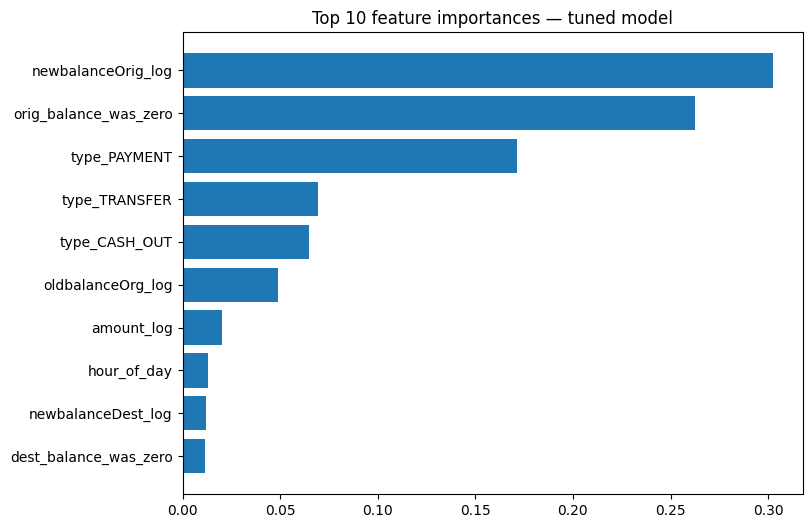

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X_train_v2.columns.tolist(),
    "importance": xgb_tuned.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8, 6))
plt.barh(importance_df.head(10)["feature"], importance_df.head(10)["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 feature importances — tuned model")
plt.show()

In [ ]:
import joblib

joblib.dump(xgb_tuned, "fraud_model_paysim_tuned.pkl")
joblib.dump(scaler, "scaler_paysim.pkl")
joblib.dump(X_train_v2.columns.tolist(), "feature_columns_paysim.pkl")

print("All artifacts saved.")

from google.colab import files
files.download("fraud_model_paysim_tuned.pkl")
files.download("scaler_paysim.pkl")
files.download("feature_columns_paysim.pkl")

All artifacts saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(xgb_tuned)

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)   # tuned model ke liye explainer
joblib.dump(explainer, "shap_explainer_paysim.pkl")
files.download("shap_explainer_paysim.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

print("=== FINAL MODEL SUMMARY ===")
print(f"Model: XGBoost (tuned)")
print(f"Training rows: {X_train_v2.shape[0]:,}")
print(f"Best params: {best_params}")
print(f"PR-AUC: {pr_auc(y_test, y_proba_tuned):.4f}")

=== FINAL MODEL SUMMARY ===
Model: XGBoost (tuned)
Training rows: 5,090,096
Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
PR-AUC: 0.9724


In [ ]:
# Sirf 1000 rows ka sample — explanation/demo ke liye kaafi hai
X_test_sample = X_test_v2.sample(n=1000, random_state=42)

shap_values = explainer.shap_values(X_test_sample)
print("Shape:", shap_values.shape)

Shape: (1000, 13)


In [ ]:
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=15)

NameError: name 'shap_values' is not defined

In [ ]:
import numpy as np

def get_top_shap_features(transaction_idx, X_data, shap_values, top_n=4):
    row_shap = shap_values[transaction_idx]
    feature_names = X_data.columns.tolist()
    feature_shap_pairs = list(zip(feature_names, row_shap))
    feature_shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    return feature_shap_pairs[:top_n]

# Sample se ek fraud case dhoondo
sample_labels = y_test.loc[X_test_sample.index]
fraud_positions = np.where(sample_labels.values == 1)[0]

if len(fraud_positions) > 0:
    sample_idx = fraud_positions[0]
    top_features = get_top_shap_features(sample_idx, X_test_sample, shap_values)
    for feature, value in top_features:
        direction = "increased" if value > 0 else "decreased"
        print(f"{feature}: {value:.3f} ({direction} fraud probability)")
else:
    print("Sample mein koi fraud case nahi mila, sample size badhao ya dobara sample lo")

oldbalanceOrg_log: 8.160 (increased fraud probability)
hour_of_day: 2.111 (increased fraud probability)
newbalanceOrig_log: 1.049 (increased fraud probability)
type_CASH_OUT: 0.796 (increased fraud probability)


In [ ]:
def transaction_to_text_summary(transaction_idx, X_data, shap_values, top_n=4):
    top_features = get_top_shap_features(transaction_idx, X_data, shap_values, top_n)
    feature_desc = ", ".join([f"{name} ({value:+.2f})" for name, value in top_features])
    return f"Top contributing factors: {feature_desc}."

summary = transaction_to_text_summary(sample_idx, X_test_sample, shap_values)
print(summary)

Top contributing factors: oldbalanceOrg_log (+8.16), hour_of_day (+2.11), newbalanceOrig_log (+1.05), type_CASH_OUT (+0.80).


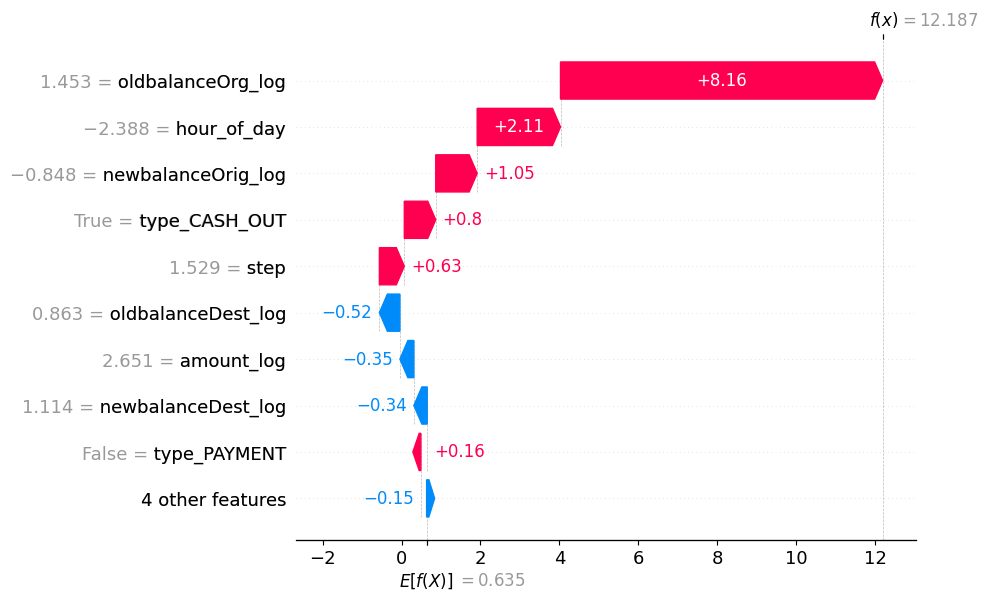

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[sample_idx],
        feature_names=X_test_sample.columns.tolist()
    )
)

In [ ]:
import joblib

joblib.dump(explainer, "shap_explainer_paysim.pkl")
print("SHAP explainer saved.")

from google.colab import files
files.download("shap_explainer_paysim.pkl")

SHAP explainer saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# Test set se ek random transaction pick karo
random_idx = np.random.randint(0, len(X_test_v2))

sample_transaction = X_test_v2.iloc[[random_idx]]
actual_label = y_test.iloc[random_idx]

# Prediction
predicted_prob = xgb_tuned.predict_proba(sample_transaction)[0][1]
predicted_label = xgb_tuned.predict(sample_transaction)[0]

print("=== Transaction Details ===")
print(sample_transaction)

print("\n=== Result ===")
print(f"Actual label: {'Fraud' if actual_label == 1 else 'Legit'}")
print(f"Predicted label: {'Fraud' if predicted_label == 1 else 'Legit'}")
print(f"Fraud probability: {predicted_prob:.4f} ({predicted_prob*100:.2f}%)")
print(f"Correct prediction: {'✓ Yes' if actual_label == predicted_label else '✗ No'}")

=== Transaction Details ===
             step  orig_balance_was_zero  dest_balance_was_zero  amount_log  \
3155411 -0.044707                      1                      0    0.189163   

         oldbalanceOrg_log  newbalanceOrig_log  oldbalanceDest_log  \
3155411          -1.307773            -0.84768            0.994603   

         newbalanceDest_log  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
3155411            0.920048           True       False         False   

         type_TRANSFER  hour_of_day  
3155411          False     1.314018  

=== Result ===
Actual label: Legit
Predicted label: Legit
Fraud probability: 0.0000 (0.00%)
Correct prediction: ✓ Yes


In [ ]:
print("df_clean shape:", df_clean.shape)
print("X_train_v2 shape:", X_train_v2.shape)
print("X_test_v2 shape:", X_test_v2.shape)
print("X_tune_sample shape:", X_tune_sample.shape)

df_clean shape: (6362620, 16)
X_train_v2 shape: (5090096, 13)
X_test_v2 shape: (1272524, 13)
X_tune_sample shape: (300000, 13)


In [ ]:
import os

for f in os.listdir():
    if f.endswith(".pkl"):
        print(f)

shap_explainer_paysim.pkl
fraud_model_paysim_baseline.pkl
feature_columns_paysim.pkl
scaler_paysim.pkl


In [ ]:
!pip install huggingface_hub -q

In [ ]:
from huggingface_hub import upload_file

REPO_ID = "Laybaatariq/fraud-detection-model"   # apna username daalo, jo Step 3 mein use kiya

files_to_upload = [
    "fraud_model_paysim_baseline.pkl",
    "scaler_paysim.pkl",
    "feature_columns_paysim.pkl",
    "shap_explainer_paysim.pkl"
]

for file in files_to_upload:
    upload_file(
        path_or_fileobj=file,
        path_in_repo=file,
        repo_id=REPO_ID,
        repo_type="model"
    )
    print(f"Uploaded: {file}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...model_paysim_baseline.pkl: 100%|##########|  773kB /  773kB            

Uploaded: fraud_model_paysim_baseline.pkl


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Uploaded: feature_columns_paysim.pkl


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...shap_explainer_paysim.pkl:  26%|##5       |  676kB / 2.63MB            

Uploaded: shap_explainer_paysim.pkl
